**Identitas: Salsabilah**

In [ ]:
!pip install scikit-learn feature-engine==1.8.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.0/375.0 kB 8.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

#Joblib
import joblib, os, warnings
warnings.filterwarnings('ignore')

#Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

#Models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# **Data Loading & Data Validation**

In [ ]:
!kaggle datasets download velvetcrystal/student-productivity-dataset

Dataset URL: https://www.kaggle.com/datasets/velvetcrystal/student-productivity-dataset
License(s): MIT
student-productivity-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q /content/student-productivity-dataset.zip

replace Student_Productivity_Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [ ]:
df=pd.read_csv('/content/Student_Productivity_Dataset.csv')
df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   object 
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motiv

In [ ]:
df.isna().sum()

,0
Student_ID,0
Age,155
Gender,119
Study_Hours_Per_Day,165
Sleep_Hours_Per_Night,106
Screen_Time_Hours,132
Social_Media_Hours,80
Attendance_Percentage,122
Assignments_Completed,118
Class_Participation_Score,185


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=[
    'Student_ID',
    'Performance_Category'], inplace=True)

# **EDA (Exploratory Data Analysis)**

In [ ]:
categorical_cols= list(df.select_dtypes(include='object').columns)
categorical_cols

['Gender', 'Internet_Quality', 'Part_Time_Job']

In [ ]:
numerical_cols= list(df.select_dtypes(include='number').columns)
numerical_cols

['Age',
 'Study_Hours_Per_Day',
 'Sleep_Hours_Per_Night',
 'Screen_Time_Hours',
 'Social_Media_Hours',
 'Attendance_Percentage',
 'Assignments_Completed',
 'Class_Participation_Score',
 'Physical_Activity_Hours_Per_Week',
 'Stress_Level',
 'Motivation_Level',
 'Extracurricular_Involvement',
 'AI_Tool_Usage_Hours_Per_Week',
 'Previous_Semester_GPA',
 'Productivity_Score']

In [ ]:
df.describe()

,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score
count,9845.000000,9835.000000,9894.000000,9868.000000,9920.000000,9878.000000,9882.000000,9815.000000,9863.000000,9846.000000,9825.000000,9822.000000,9860.000000,9839.000000,10000.000000
mean,20.134891,4.219583,6.976602,6.047862,3.032107,79.817301,74.251872,5.991218,3.200862,5.542840,5.957924,4.050204,5.544726,6.489753,54.607333
std,2.497517,1.950639,1.303614,2.424031,1.729774,12.348369,16.588029,2.150297,2.252450,2.107599,2.111982,2.367947,3.892723,1.580462,12.340640
min,16.000000,0.000000,3.000000,1.000000,0.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.800000,6.100000,4.300000,1.800000,71.200000,62.900000,4.500000,1.600000,4.100000,4.500000,2.300000,2.700000,5.415000,46.640000
50%,20.000000,4.200000,7.000000,6.000000,3.000000,80.200000,74.900000,6.000000,2.700000,5.600000,6.000000,4.000000,4.700000,6.500000,54.935000
75%,22.000000,5.600000,7.900000,7.700000,4.200000,89.100000,86.800000,7.500000,4.300000,7.000000,7.400000,5.700000,7.500000,7.590000,63.032500
max,25.000000,12.000000,10.000000,14.800000,9.700000,100.000000,100.000000,10.000000,15.000000,10.000000,10.000000,10.000000,25.000000,10.000000,100.000000


In [ ]:
numerical_cols

['Age',
 'Study_Hours_Per_Day',
 'Sleep_Hours_Per_Night',
 'Screen_Time_Hours',
 'Social_Media_Hours',
 'Attendance_Percentage',
 'Assignments_Completed',
 'Class_Participation_Score',
 'Physical_Activity_Hours_Per_Week',
 'Stress_Level',
 'Motivation_Level',
 'Extracurricular_Involvement',
 'AI_Tool_Usage_Hours_Per_Week',
 'Previous_Semester_GPA',
 'Productivity_Score']

In [ ]:
for col in categorical_cols:
    modus_nilai = df[col].mode()[0]
    df[col] = df[col].fillna(modus_nilai)

In [ ]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
for col in numerical_cols:
    stat, p = stats.normaltest(df[col], nan_policy='omit')
    print(f"{col}: p-value = {p:.4f}")

Age: p-value = 0.0000
Study_Hours_Per_Day: p-value = 0.0000
Sleep_Hours_Per_Night: p-value = 0.0000
Screen_Time_Hours: p-value = 0.0000
Social_Media_Hours: p-value = 0.0000
Attendance_Percentage: p-value = 0.0000
Assignments_Completed: p-value = 0.0000
Class_Participation_Score: p-value = 0.0000
Physical_Activity_Hours_Per_Week: p-value = 0.0000
Stress_Level: p-value = 0.0000
Motivation_Level: p-value = 0.0000
Extracurricular_Involvement: p-value = 0.0000
AI_Tool_Usage_Hours_Per_Week: p-value = 0.0000
Previous_Semester_GPA: p-value = 0.0000
Productivity_Score: p-value = 0.0000


=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 1205.0802
p-value: 2.0900171912275558e-262

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


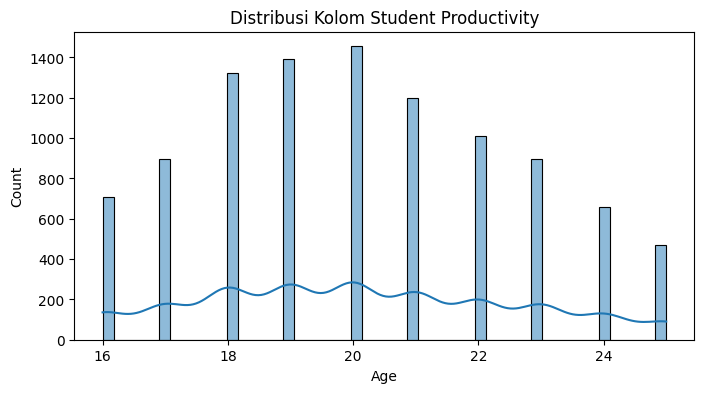

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 44.0096
p-value: 2.776172966069787e-10

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


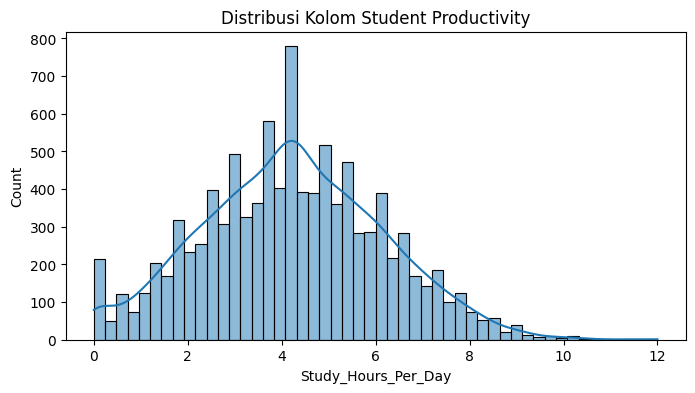

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 23.1509
p-value: 9.394083256495534e-06

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


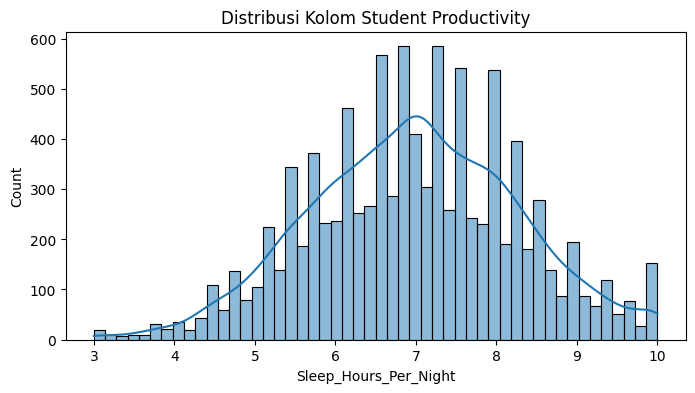

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 47.1082
p-value: 5.896483835275792e-11

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


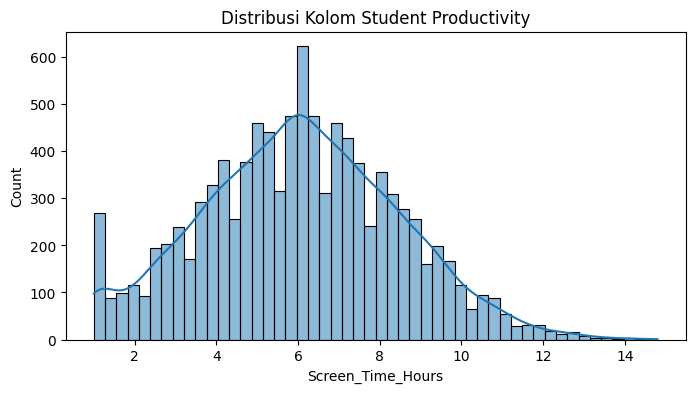

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 156.1452
p-value: 1.2402507840809176e-34

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


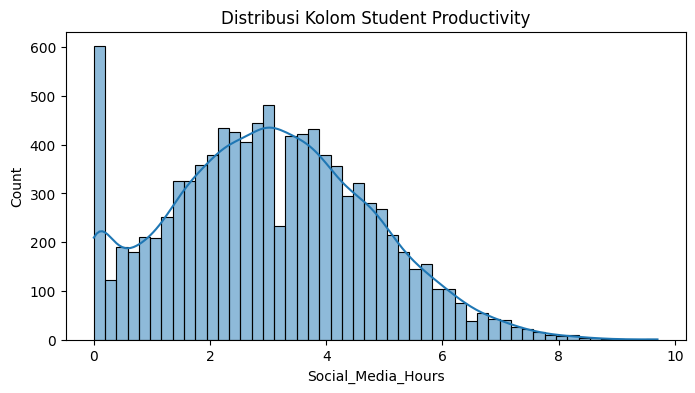

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 233.0878
p-value: 2.4301187374364255e-51

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


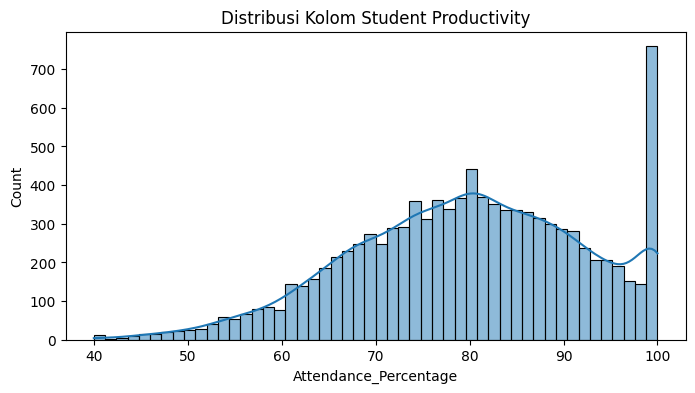

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 227.1426
p-value: 4.749021397123434e-50

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


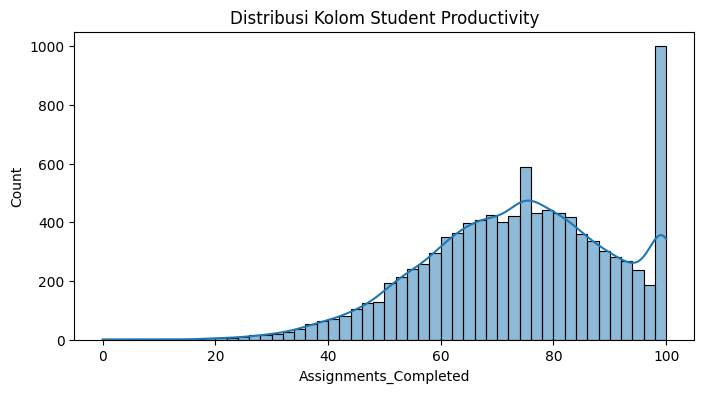

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 122.0529
p-value: 3.1373082244416356e-27

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


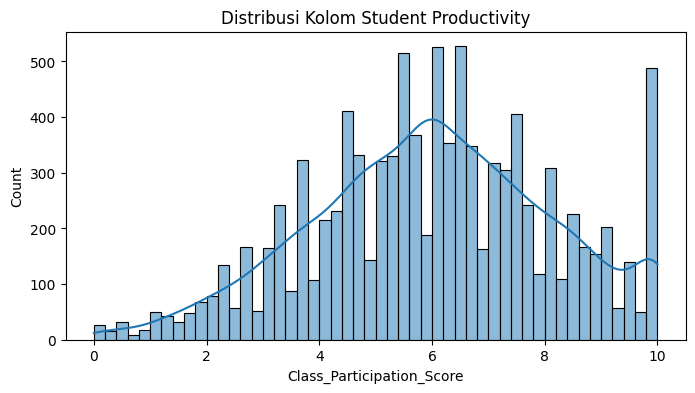

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 2638.5513
p-value: 0.0

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


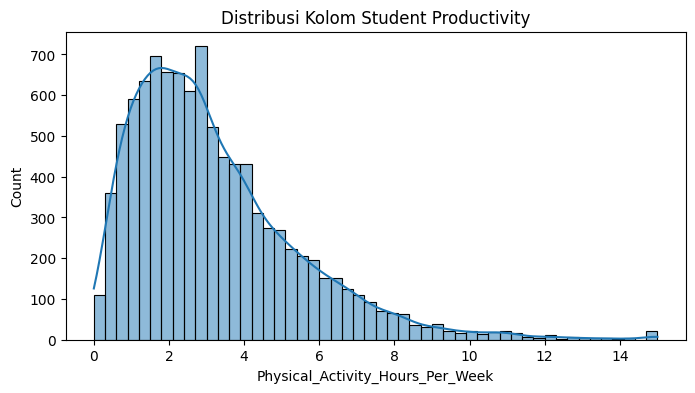

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 151.2986
p-value: 1.399342566423351e-33

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


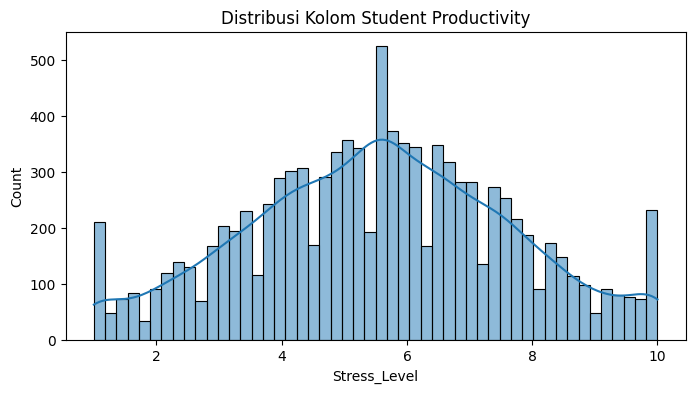

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 142.8583
p-value: 9.521553677054245e-32

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


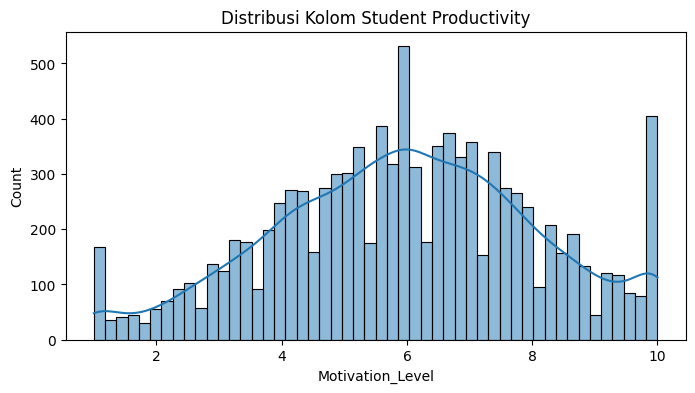

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 291.1849
p-value: 5.888456287785265e-64

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


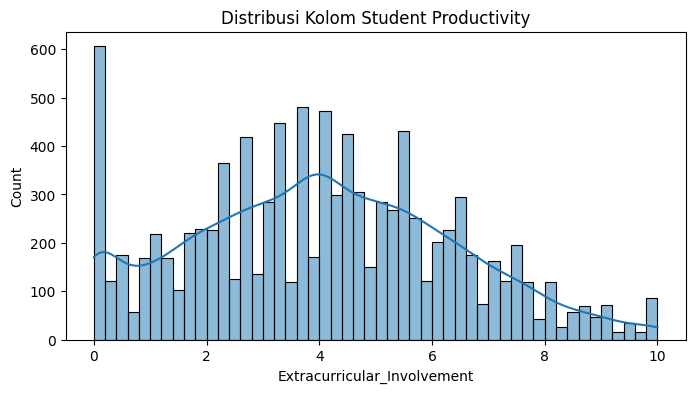

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 2401.9027
p-value: 0.0

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


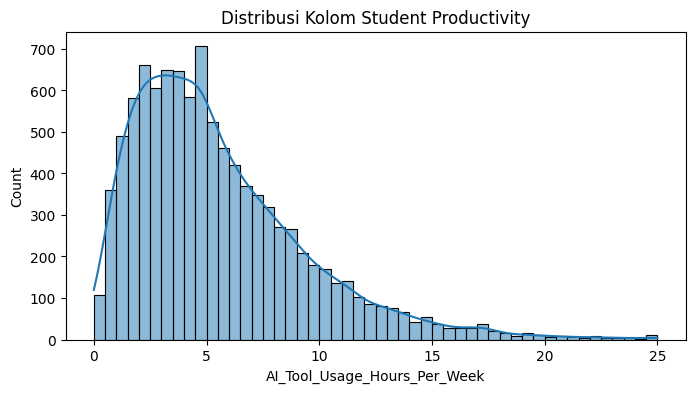

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 31.6476
p-value: 1.342161709715807e-07

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


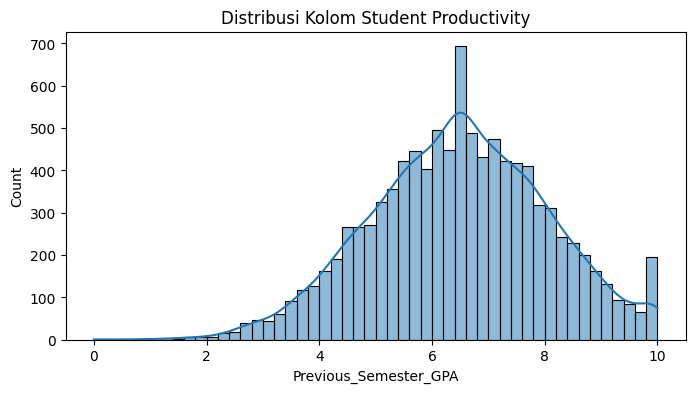

=== Hasil D’Agostino’s K^2 Test ===
Statistik Uji (K^2): 126.7768
p-value: 2.9564377883082643e-28

Kesimpulan: Data TIDAK NORMAL (Menolak H0)


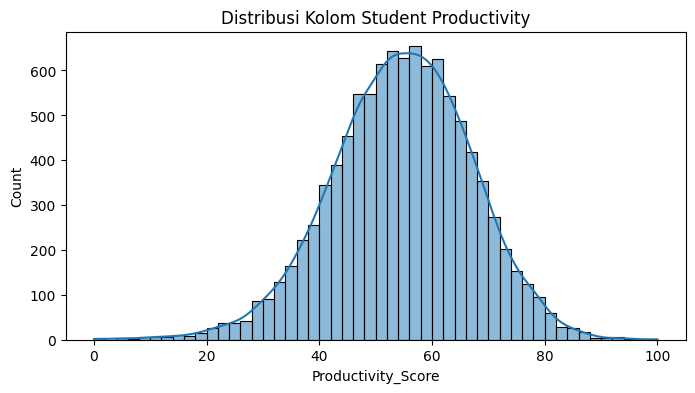

In [ ]:
numerical_cols= list(df.select_dtypes(include='number').columns)

column_of_not_distributed = []
column_of_distributed = []
#Normality Test
for column in numerical_cols:

    stat, p_value = stats.normaltest(df[column].dropna())

    print("=== Hasil D’Agostino’s K^2 Test ===")
    print(f"Statistik Uji (K^2): {stat:.4f}")
    print(f"p-value: {p_value}")

#Condition
    alpha = 0.05
    if p_value > alpha:
        column_of_distributed.append(column)
        print("\nKesimpulan: Data berdistribusi NORMAL (Gagal menolak H0)")
    else:
        column_of_not_distributed.append(column)
        print("\nKesimpulan: Data TIDAK NORMAL (Menolak H0)")

#Visualization
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True, bins=50)
    plt.title("Distribusi Kolom Student Productivity")
    plt.show()

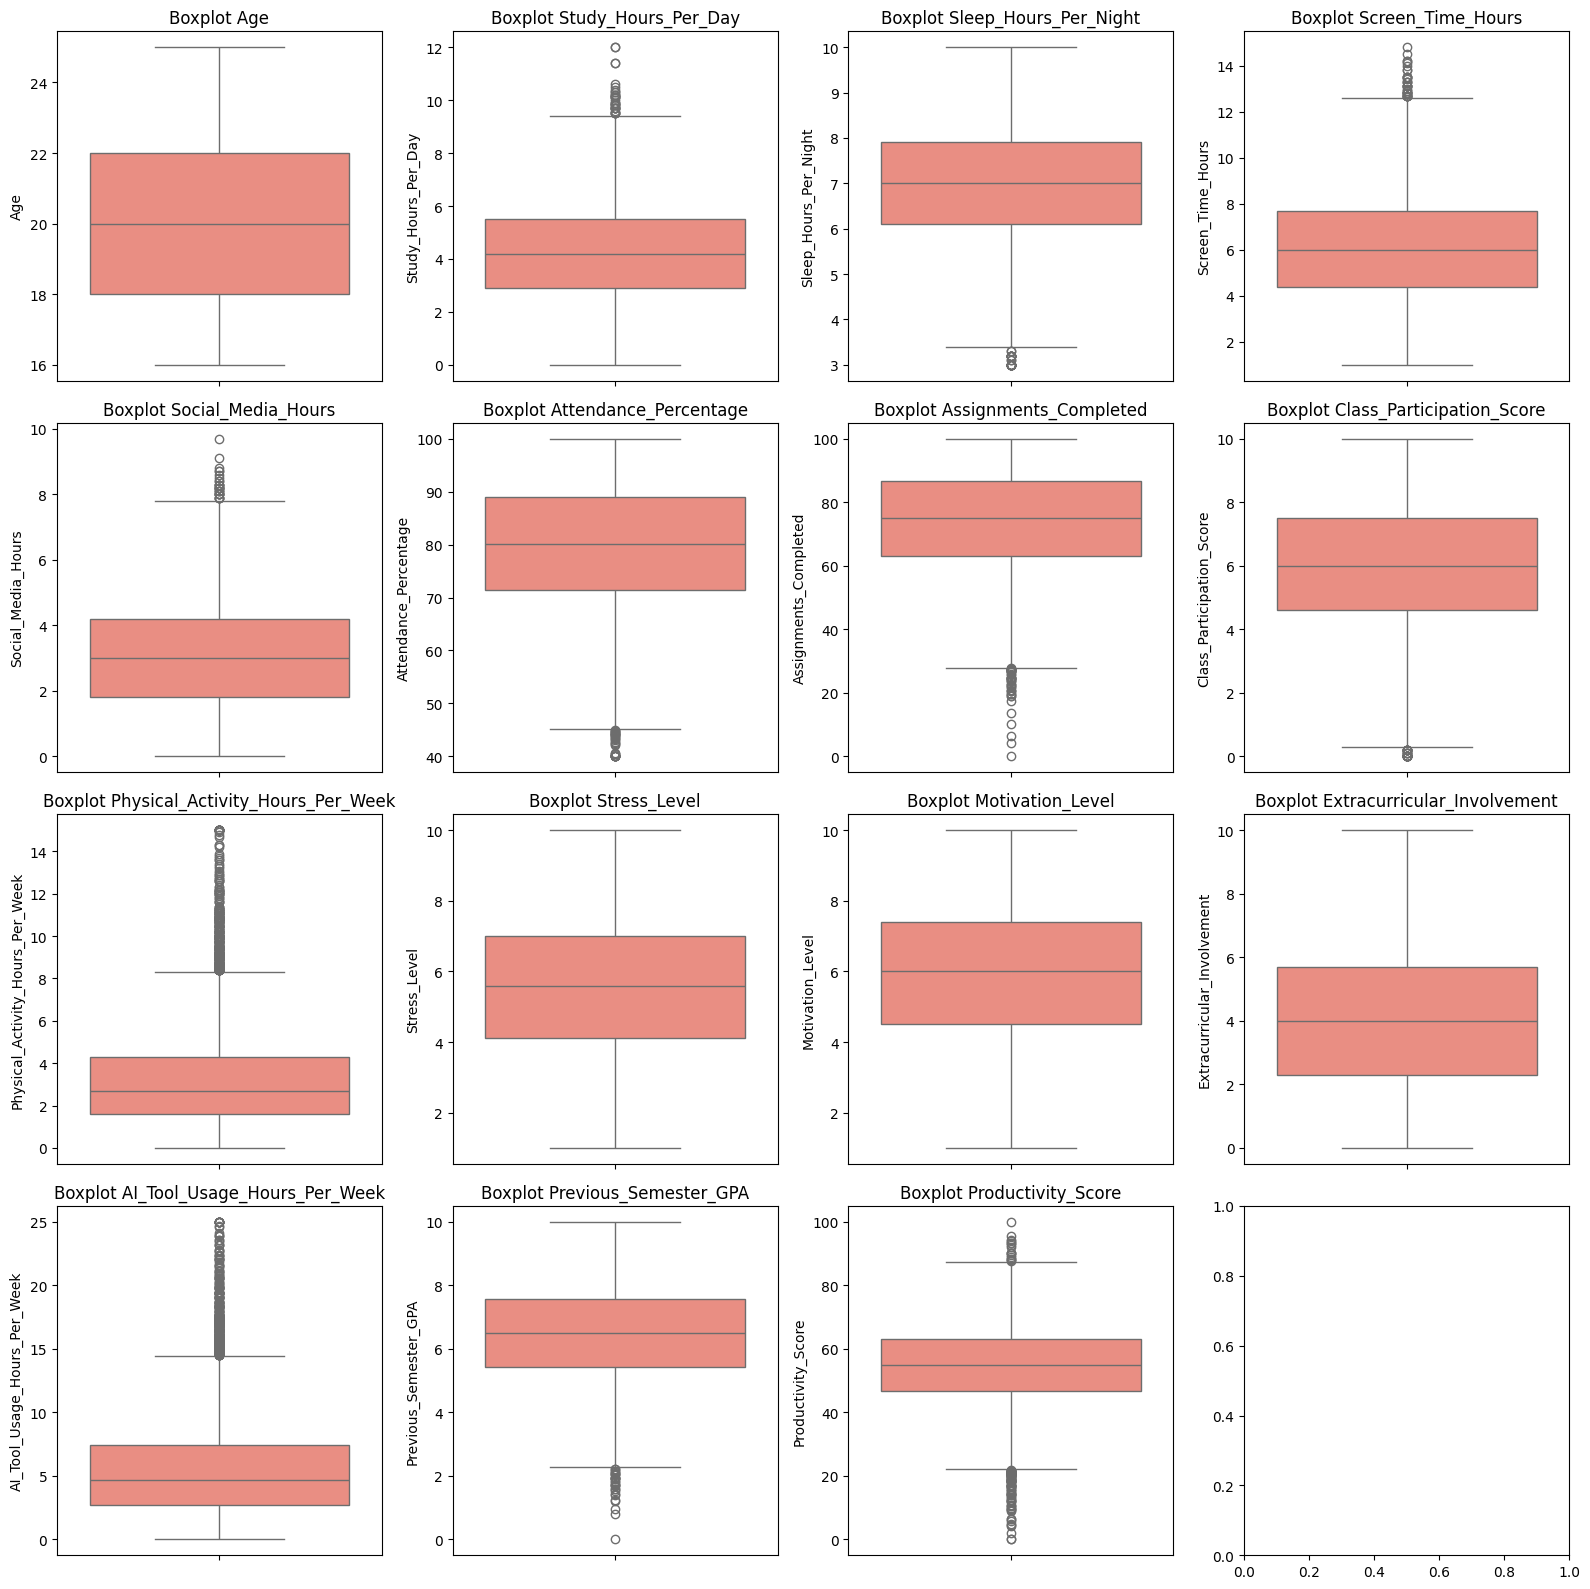

In [ ]:
#Outlier Checking
import math

n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
ax = ax.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=ax[i], color='salmon')
    ax[i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

In [ ]:
#Outlier Handling
df_clean = df.copy()

print("=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===")

for col in numerical_cols:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1

  low_bound = Q1 - 1.5 * IQR
  up_bound = Q3 + 1.5 * IQR

  total_rows = len(df_clean)


  outlier_mask = (df_clean[col] < low_bound) | (df_clean[col] > up_bound)
  num_outliers = outlier_mask.sum()
  keep_mask = ~outlier_mask


  df_clean = df_clean[keep_mask]


  print(f'Atribut: {col}')
  print(f'Q1: {Q1:.2f}')
  print(f'Q3: {Q3:.2f}')
  print(f'IQR: {IQR:.2f}')
  print(f'Upper Boundary: {up_bound:.2f}')
  print(f'Lower Boundary: {low_bound:.2f}')
  print(f'Jumlah Outlier: {num_outliers}')
  print(f'Percentage of outliers: {(num_outliers * 100 / total_rows):.2f}%')
  print('=' * 50)

=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===
Atribut: Age
Q1: 18.00
Q3: 22.00
IQR: 4.00
Upper Boundary: 28.00
Lower Boundary: 12.00
Jumlah Outlier: 0
Percentage of outliers: 0.00%
Atribut: Study_Hours_Per_Day
Q1: 2.90
Q3: 5.50
IQR: 2.60
Upper Boundary: 9.40
Lower Boundary: -1.00
Jumlah Outlier: 33
Percentage of outliers: 0.33%
Atribut: Sleep_Hours_Per_Night
Q1: 6.10
Q3: 7.90
IQR: 1.80
Upper Boundary: 10.60
Lower Boundary: 3.40
Jumlah Outlier: 30
Percentage of outliers: 0.30%
Atribut: Screen_Time_Hours
Q1: 4.40
Q3: 7.70
IQR: 3.30
Upper Boundary: 12.65
Lower Boundary: -0.55
Jumlah Outlier: 35
Percentage of outliers: 0.35%
Atribut: Social_Media_Hours
Q1: 1.80
Q3: 4.20
IQR: 2.40
Upper Boundary: 7.80
Lower Boundary: -1.80
Jumlah Outlier: 30
Percentage of outliers: 0.30%
Atribut: Attendance_Percentage
Q1: 71.40
Q3: 89.00
IQR: 17.60
Upper Boundary: 115.40
Lower Boundary: 45.00
Jumlah Outlier: 30
Percentage of outliers: 0.30%
Atribut: Assignments_Completed
Q1: 63.10
Q3: 86.60
IQR: 23.5

In [ ]:
# cek hubungan fitur dan target dengan korelasi
df_clean[numerical_cols].corr(method='pearson').style.background_gradient(cmap='rocket')

,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score
Age,1.000000,-0.013853,-0.001881,-0.010199,-0.021142,-0.000636,0.012492,0.014564,0.001915,0.007272,0.001332,-0.005865,-0.000256,-0.009248,0.012973
Study_Hours_Per_Day,-0.013853,1.000000,-0.001640,0.011668,0.002174,-0.013941,-0.027559,-0.016074,-0.001131,0.009690,0.006178,-0.008677,0.009976,0.003781,0.162137
Sleep_Hours_Per_Night,-0.001881,-0.001640,1.000000,0.018507,0.006413,0.002508,0.002986,0.002573,0.012539,-0.007667,-0.009804,-0.017838,-0.002697,-0.004824,0.303480
Screen_Time_Hours,-0.010199,0.011668,0.018507,1.000000,0.005381,0.000371,0.000413,0.011366,0.018634,-0.017741,0.000563,-0.000742,-0.007353,0.000303,-0.214200
Social_Media_Hours,-0.021142,0.002174,0.006413,0.005381,1.000000,-0.002922,0.022391,0.013065,0.013200,-0.002201,0.003563,-0.016249,-0.009912,0.012720,-0.105274
Attendance_Percentage,-0.000636,-0.013941,0.002508,0.000371,-0.002922,1.000000,0.000666,0.004587,-0.014592,0.003433,-0.007869,0.004905,-0.025216,0.000601,0.286490
Assignments_Completed,0.012492,-0.027559,0.002986,0.000413,0.022391,0.000666,1.000000,-0.035175,-0.006794,0.005404,-0.012327,0.011224,0.002799,0.002012,0.287239
Class_Participation_Score,0.014564,-0.016074,0.002573,0.011366,0.013065,0.004587,-0.035175,1.000000,-0.011316,0.011954,-0.014102,-0.012374,0.004499,0.012883,0.239847
Physical_Activity_Hours_Per_Week,0.001915,-0.001131,0.012539,0.018634,0.013200,-0.014592,-0.006794,-0.011316,1.000000,-0.011100,0.017286,-0.010733,-0.011996,-0.000036,0.174402
Stress_Level,0.007272,0.009690,-0.007667,-0.017741,-0.002201,0.003433,0.005404,0.011954,-0.011100,1.000000,0.014959,-0.001771,-0.025852,0.003523,-0.209472


# **Data Preprocessing**

In [ ]:
# Splitting antara `X` and `y`
X = df_clean.drop(['Productivity_Score'], axis=1)
y = df_clean['Productivity_Score']


In [ ]:
# Splitting between Train-Set, Val-Set, and Test-Set

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42)

print('Train Size : ', X_train.shape)
print('Val Size   : ', X_val.shape)
print('Test Size  : ', X_test.shape)

Train Size :  (6539, 17)
Val Size   :  (1155, 17)
Test Size  :  (1358, 17)


In [ ]:
#Pipeline (impute, encode and scale)
ordinal_cols   = ['Internet_Quality', 'Part_Time_Job']
ohe_cols       = ['Gender']
numerical_cols = [col for col in X_train.columns if col not in ordinal_cols + ohe_cols]

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[
        ['Poor', 'Average', 'Good'],
        ['No', 'Yes']
    ])),
    ('scaler', StandardScaler())
])

ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(sparse_output=False, drop='first'))
])

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('ordinal',   ordinal_pipeline,   ordinal_cols),
    ('ohe',       ohe_pipeline,       ohe_cols),
    ('numerical', numerical_pipeline, numerical_cols)
])

In [ ]:
X_train_clean = preprocessor.fit_transform(X_train)
X_val_clean  = preprocessor.transform(X_val)
X_test_clean  = preprocessor.transform(X_test)

In [ ]:
feature_names = preprocessor.get_feature_names_out()
X_train_clean = pd.DataFrame(X_train_clean, columns=feature_names, index=X_train.index)
X_val_clean  = pd.DataFrame(X_val_clean,  columns=feature_names, index=X_val.index)
X_test_clean  = pd.DataFrame(X_test_clean,  columns=feature_names, index=X_test.index)

# **Sequential API**

In [ ]:
#Clear
seed = 42
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# Create Sequential API
n_features = X_train_clean.shape[1]

model_ann = Sequential()

#Hidden layer 1 + input layer
model_ann.add(Dense(128,
                    activation='relu',
                    kernel_initializer=tf.keras.initializers.HeNormal(seed),
                           input_shape=(n_features,)))
model_ann.add(BatchNormalization())
model_ann.add(Dropout(0.2))

#Hidden layer 2
model_ann.add(Dense(64,
                    activation='relu',
                    kernel_initializer=tf.keras.initializers.HeNormal(seed)))
model_ann.add(BatchNormalization())
model_ann.add(Dropout(0.1))

#Hidden layer 3
model_ann.add(Dense(32,
                    activation='relu',
                    kernel_initializer=tf.keras.initializers.HeNormal(seed)))
model_ann.add(BatchNormalization())

#output layer
model_ann.add(Dense(1,
                    activation='linear',
                    kernel_initializer=tf.keras.initializers.GlorotNormal(seed)))

#Compile
model_ann.compile(loss='mse',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                         metrics=['mae'])
model_ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,249 (51.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Callbacks
os.makedirs('models', exist_ok=True)
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=20,
                               restore_best_weights=True,
                               verbose= 1)

model_checkpoint = ModelCheckpoint('best_model.keras',
                                   monitor='val_loss',
                                   save_best_only=True,
                                   verbose= 1)

callbacks = [early_stopping, model_checkpoint]

In [ ]:
# Train the model
%%time

history= model_ann.fit(X_train_clean,
                       y_train,
                       epochs=300,
                       validation_data=(X_val_clean, y_val),
                       batch_size=32,
                       callbacks=callbacks)

Epoch 1/300
198/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3074.0519 - mae: 54.5716
Epoch 1: val_loss improved from None to 2718.84326, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2970.9854 - mae: 53.8357 - val_loss: 2718.8433 - val_mae: 51.7433
Epoch 2/300
186/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2533.3068 - mae: 49.8106
Epoch 2: val_loss improved from 2718.84326 to 1799.20813, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2308.0413 - mae: 47.4634 - val_loss: 1799.2081 - val_mae: 41.9717
Epoch 3/300
191/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1592.5701 - mae: 39.2537
Epoch 3: val_loss improved from 1799.20813 to 855.23877, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1343.5952 - mae: 35.8414 - val_loss: 855.

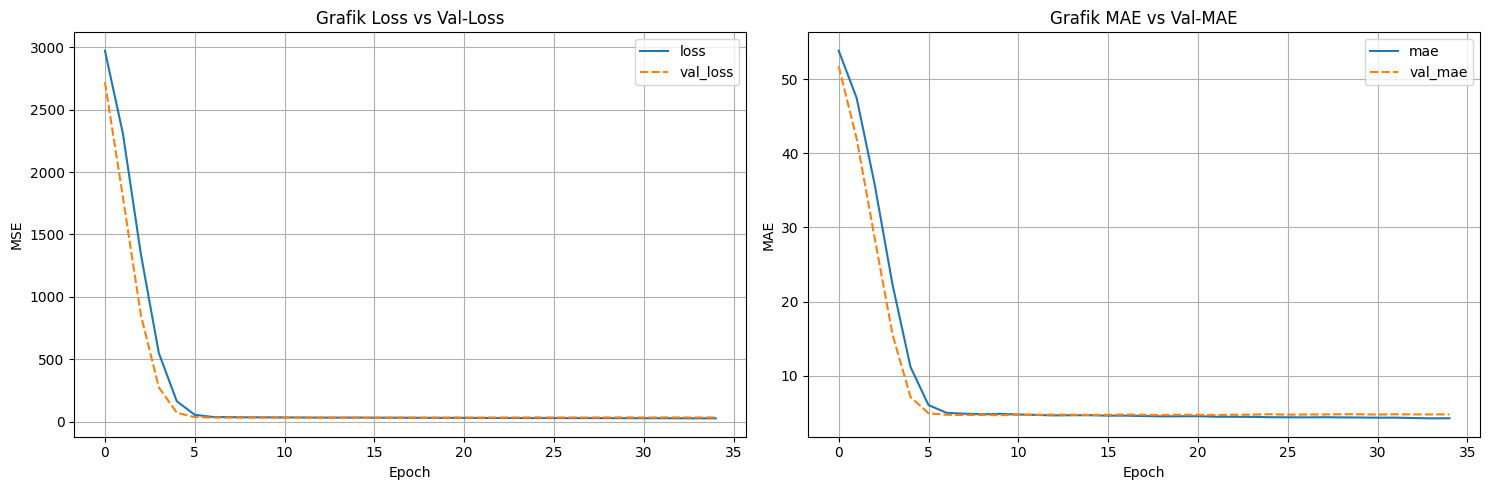

In [ ]:
# Plot training result
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.lineplot(data=history_df[['loss', 'val_loss']])
plt.grid()
plt.title('Grafik Loss vs Val-Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_df[['mae', 'val_mae']])
plt.grid()
plt.title('Grafik MAE vs Val-MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

In [ ]:
y_pred_test  = model_ann.predict(X_test_clean).flatten()
y_pred_train = model_ann.predict(X_train_clean).flatten()

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
#Evaluation
print(f"  R²   Train : {r2_score(y_train, y_pred_train):.4f}  |  Test : {r2_score(y_test, y_pred_test):.4f}")
print(f"  MAE  Train : {mean_absolute_error(y_train, y_pred_train):.4f}  |  Test : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"  RMSE Train : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}  |  Test : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

  R²   Train : 0.8096  |  Test : 0.7616
  MAE  Train : 3.9881  |  Test : 4.5180
  RMSE Train : 5.0341  |  Test : 5.7160


In [ ]:
# Freeze model
model_ann.trainable = False
model_ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,197 (157.02 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 13,697 (53.50 KB)

 Optimizer params: 26,500 (103.52 KB)

In [ ]:
import os
# SAVING ANN + PREPROCESSOR
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
ann_name  = f"student_productivity_ann_{timestamp}.keras"

model_ann.save(f"models/{ann_name}")
joblib.dump(preprocessor, 'models/preprocessor.pkl')

# Metadata
import json

# Calculate test metrics for metadata
ann_metrics = {
    'R² Test': r2_score(y_test, y_pred_test),
    'MAE Test': mean_absolute_error(y_test, y_pred_test),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test))
}

metadata_ann = {
    'project':          'Student Productivity Prediction — MP2',
    'model_type':       'ANN (TensorFlow/Keras)',
    'date_trained':     datetime.now().isoformat(),
    'epochs_trained':   len(history.history['loss']),
    'architecture':     '128→64→32→1 (ReLU, Dropout, BatchNorm)',
    'optimizer':        'Adam (lr=0.001)',
    'loss_function':    'MSE',
    'regularization':   'Dropout (0.2, 0.1) + EarlyStopping + ModelCheckpoint',
    'test_r2':          round(ann_metrics['R² Test'], 4),
    'test_mae':         round(ann_metrics['MAE Test'], 4),
    'test_rmse':        round(ann_metrics['RMSE Test'], 4),
    'features':         X_train_clean.columns.tolist(),
    'n_features':       int(X_train_clean.shape[1]),
    'best_model_file':  ann_name,
    'preprocessor':     'preprocessor.pkl',
}

with open('models/ann_metadata.json', 'w') as f:
    json.dump(metadata_ann, f, indent=2)

print(f"✓ ANN model saved     : {ann_name}")
print(f"✓ Preprocessor saved  : preprocessor.pkl")
print(f"✓ Metadata saved      : ann_metadata.json")
print()
print("📦 Semua file di folder models/")
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"   {f}  ({size:.1f} KB)")

✓ ANN model saved     : student_productivity_ann_20260622_142517.keras
✓ Preprocessor saved  : preprocessor.pkl
✓ Metadata saved      : ann_metadata.json

📦 Semua file di folder models/
   ann_best_model.keras  (208.4 KB)
   ann_metadata.json  (1.2 KB)
   preprocessor.pkl  (6.7 KB)
   student_productivity_ann_20260622_141820.keras  (208.4 KB)
   student_productivity_ann_20260622_142259.keras  (208.4 KB)
   student_productivity_ann_20260622_142517.keras  (208.4 KB)


In [ ]:
# Jalankan di Colab — langsung download tanpa perlu Google Drive
from google.colab import files

files.download('models/ann_best_model.keras')
files.download('models/preprocessor.pkl')
files.download('models/ann_metadata.json')

print("✅ Semua file sedang didownload ke laptop")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Semua file sedang didownload ke laptop
